#MASTER INTERNET DE LAS COSAS

#PROBLEMA DE CLASIFICACIÓN DE AFORO
Gissela Tasiguano

Contenido:

    1. ¿Qué es la clasificación de aforo?
    2. Problema a resolver
    3. El set de datos a utilizar y librerías a usar
    4. Preprocesamiento y Análisis
    5. Modelo Random Forest
    6. Aplicación de XAI

## 1. ¿Qué es la clasificación de aforo?
La clasificación de aforo consiste en predecir el nivel de ocupación (Bajo, Medio o Alto) usando datos capturados por sensores IoT mediante un modelo de clasificación supervisada.


## 2. Problema  a resolver
El objetivo es estimar el nivel de aforo de un espacio interior a partir de variables ambientales y de conectividad, formulado como un problema de clasificación multiclase.

## 3. Set de datos a utilizar y librerías empleadas

El dataset incluye variables ambientales y de conectividad (Longitud, Latitud, Temperatura, Humedad, eCO₂, Redes y Señal Detectada). Para el análisis se emplearon **pandas**, **numpy**, **scikit‑learn**, **matplotlib**, **seaborn**, **Pipeline**, **joblib** y **SHAP** para la explicación del modelo.


## 4. Librerías Empleadas

Se emplearon **pandas**, **numpy**, **matplotlib**, **scikit‑learn** (train_test_split, GridSearchCV, StratifiedKFold, RandomForestClassifier, Pipeline, StandardScaler), **joblib**, **os**, **google.colab** y **SHAP** para cargar datos, entrenar el modelo y generar explicaciones XAI.

# Análisis exploratorio (EDA), preprocesamiento y preparación para el entrenamiento

## 1. Montar Google Drive

El conjunto de datos se encuentra almacenado en Google Drive. Para acceder al archivo desde Google Colab se realiza el montaje de la unidad, permitiendo cargar el dataset directamente en el entorno de trabajo.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Importación de librerías

Se importan las librerías necesarias para la manipulación de datos, visualización gráfica y análisis estadístico. Pandas se utiliza para el manejo de estructuras de datos, NumPy para operaciones numéricas y Matplotlib y Seaborn para la visualización de información, scikit‑learn(train_test_split, GridSearchCV, StratifiedKFold, RandomForestClassifier, Pipeline, StandardScaler), joblib, os, google.colab y SHAP para cargar datos, entrenar el modelo y generar explicaciones XAI.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import shap
import joblib
import os
from sklearn.pipeline import Pipeline
from google.colab import drive
from sklearn.preprocessing import StandardScaler
import seaborn as sns

sns.set_style("whitegrid")

## 3. Carga del dataset

Se carga el conjunto de datos desde Google Drive y se almacena en un DataFrame de Pandas para facilitar su análisis.

In [ ]:
ruta = "/content/drive/MyDrive/TFM_Dataset/dataset.csv"
df = pd.read_csv(ruta, encoding="latin1")
df.head()


,Fecha,Longitud,Latitud,Temperatura,Humedad,eCo2,Aforo,Redes,Señal Detectada
0,2026-03-25 15:27:22,40.423592,-3.675763,23.42,33.52,400,AFORO BAJO,4,-43
1,2026-03-25 15:27:30,40.423592,-3.675763,23.43,33.10,400,AFORO BAJO,4,-42
2,2026-03-25 15:27:38,40.423592,-3.675763,23.43,32.67,400,AFORO BAJO,4,-40
3,2026-03-25 15:27:46,40.423592,-3.675763,23.43,32.52,420,AFORO BAJO,3,-53
4,2026-03-25 15:27:55,40.423592,-3.675763,23.44,32.49,425,AFORO BAJO,3,-28


## 4. Exploración inicial

Se realiza una inspección inicial del conjunto de datos para conocer su estructura, número de registros, tipos de datos y variables disponibles.

In [ ]:
print("Dimensiones:", df.shape)

df.info()

Dimensiones: (997, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 997 entries, 0 to 996
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Fecha            997 non-null    object 
 1   Longitud         997 non-null    float64
 2   Latitud          997 non-null    float64
 3   Temperatura      997 non-null    float64
 4   Humedad          997 non-null    float64
 5   eCo2             997 non-null    int64  
 6   Aforo            997 non-null    object 
 7   Redes            997 non-null    int64  
 8   Señal Detectada  997 non-null    int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 70.2+ KB


## 5. Estadística descriptiva

Se calculan estadísticas descriptivas de las variables numéricas para conocer medidas de tendencia central y dispersión como media, desviación estándar, valores mínimos y máximos.

In [ ]:
df.describe()

,Longitud,Latitud,Temperatura,Humedad,eCo2,Redes,Señal Detectada
count,997.000000,997.000000,997.000000,997.000000,997.000000,997.000000,997.000000
mean,40.421013,-3.709333,25.365587,36.678385,837.090271,2.598796,-48.259779
std,0.012601,0.013038,1.548338,5.518265,325.513104,1.726686,13.691440
min,40.405170,-3.722903,22.850000,26.500000,400.000000,0.000000,-100.000000
25%,40.408661,-3.718102,23.740000,32.450000,612.000000,1.000000,-58.000000
50%,40.420723,-3.714003,25.440000,36.570000,764.000000,2.000000,-52.000000
75%,40.429218,-3.705385,26.430000,40.310000,934.000000,3.000000,-38.000000
max,40.448727,-3.675763,30.070000,64.890000,2447.000000,16.000000,-13.000000


## 6. Identificación de variables numéricas y categóricas

Se clasifican las variables según su tipo de dato para determinar las técnicas de análisis y preprocesamiento más adecuadas.

In [ ]:
numericas = df.select_dtypes(include=np.number).columns

categoricas = df.select_dtypes(exclude=np.number).columns

print("Variables numéricas:")
print(numericas)

print("\nVariables categóricas:")
print(categoricas)

Variables numéricas:
Index(['Longitud', 'Latitud', 'Temperatura', 'Humedad', 'eCo2', 'Redes',
       'Señal Detectada'],
      dtype='object')

Variables categóricas:
Index(['Fecha', 'Aforo'], dtype='object')


## 7. Conteo de variables

Se contabilizan las variables numéricas y categóricas presentes en el conjunto de datos.

In [ ]:
print("Cantidad de variables numéricas:", len(numericas))
print("Cantidad de variables categóricas:", len(categoricas))

Cantidad de variables numéricas: 7
Cantidad de variables categóricas: 2


## 8. Análisis de valores nulos

Se verifica la existencia de valores faltantes debido a que estos pueden afectar el rendimiento de los modelos de aprendizaje automático.

In [ ]:
df.isnull().sum()

,0
Fecha,0
Longitud,0
Latitud,0
Temperatura,0
Humedad,0
eCo2,0
Aforo,0
Redes,0
Señal Detectada,0


## 9. Eliminación de valores nulos

Debido a que no se identificaron valores faltantes, no fue necesario eliminar registros. Sin embargo, se incluye el procedimiento estándar para futuras aplicaciones.

In [ ]:
df = df.dropna()

print(df.shape)

(997, 9)


## 10. Análisis de variable objetivo

La variable objetivo del proyecto es "Aforo", la cual representa el nivel de ocupación detectado. Se analiza su distribución para identificar posibles desbalances entre clases.

In [ ]:
df["Aforo"].value_counts()

,count
Aforo,
AFORO MEDIO,437
AFORO BAJO,407
AFORO ALTO,153


## 11. Distribución de clases

Se representa gráficamente la distribución de las categorías de aforo para evaluar la proporción de ejemplos disponibles para cada clase.

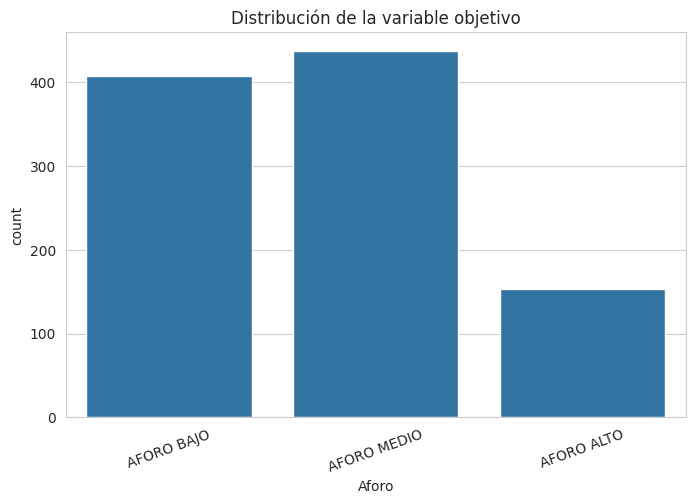

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Aforo"
)

plt.title("Distribución de la variable objetivo")
plt.xticks(rotation=20)

plt.show()

## 11.1 Porcentaje de cada clase

In [ ]:
porcentaje = (
    df["Aforo"]
    .value_counts(normalize=True)
    *100
)

print(porcentaje)

Aforo
AFORO MEDIO    43.831494
AFORO BAJO     40.822467
AFORO ALTO     15.346038
Name: proportion, dtype: float64


## 12. Corrección de etiquetas inconsistentes

Durante el análisis se identificó una posible inconsistencia en las etiquetas de la variable objetivo. La categoría "MEDIA GENTE" presenta el mismo significado semántico que "AFORO MEDIO", por lo que ambas se unifican.

In [ ]:
df["Aforo"] = df["Aforo"].replace({
    "MEDIA GENTE":"AFORO MEDIO"
})

## 13. Conversión de dataset

La variable temporal se transforma al formato datetime para facilitar la extracción de características relacionadas con el comportamiento temporal del aforo.

In [ ]:
print(df.columns)

Index(['Fecha', 'Longitud', 'Latitud', 'Temperatura', 'Humedad', 'eCo2',
       'Aforo', 'Redes', 'Señal Detectada'],
      dtype='object')


In [ ]:
# Convertir la columna Fecha a datetime (si no lo está)
df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")

# Crear SOLO la variable Hora
df["Hora"] = df["Fecha"].dt.hour


## 14. Eliminación de fecha original

Una vez extraídas las características temporales, la variable fecha original se elimina para evitar redundancia en el conjunto de datos.

In [ ]:
df.drop("Fecha", axis=1, inplace=True)

## 15. Distribución de variables numéricas

Se analiza la distribución de las variables numéricas para identificar posibles sesgos, anomalías o comportamientos atípicos.

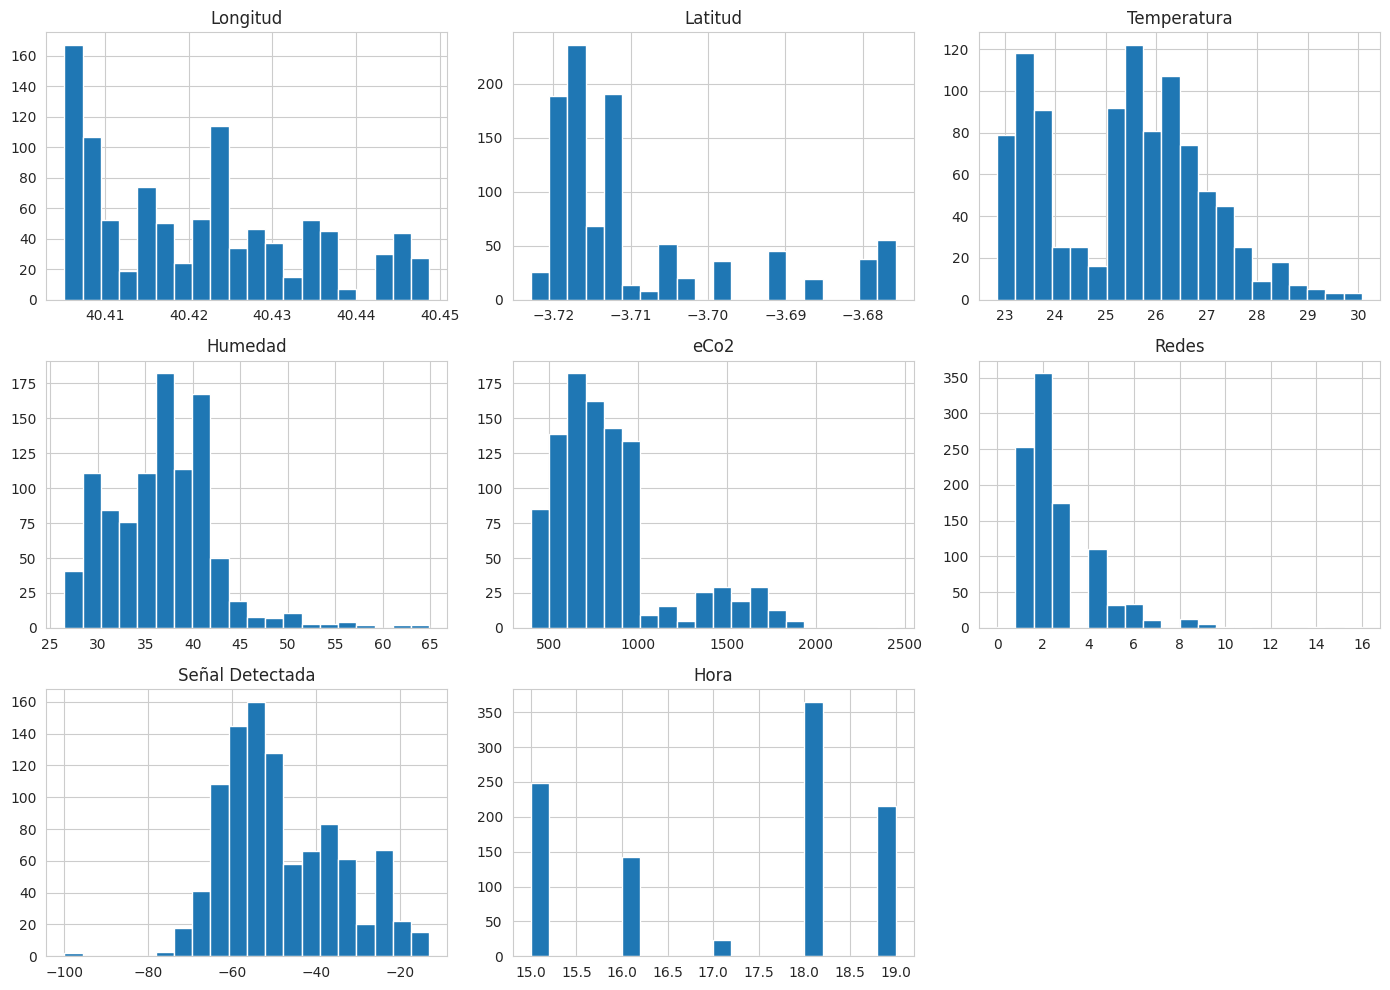

In [ ]:
df.hist(
    figsize=(14,10),
    bins=20
)

plt.tight_layout()
plt.show()

## 16. Matriz de correlación

Se analiza la relación lineal entre variables numéricas mediante una matriz de correlación.

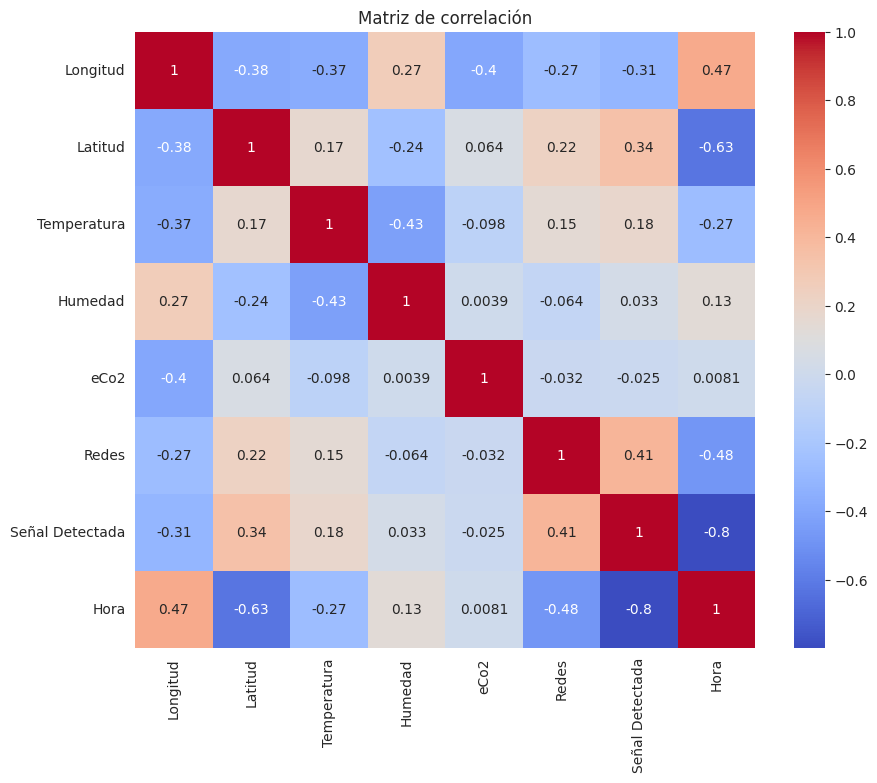

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Matriz de correlación")

plt.show()

## 17. Codificación de la variable objetivo

Los algoritmos de aprendizaje automático requieren variables objetivo numéricas, por lo que se aplica una codificación mediante Label Encoding.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Aforo"] = le.fit_transform(df["Aforo"])

df.head()

,Longitud,Latitud,Temperatura,Humedad,eCo2,Aforo,Redes,Señal Detectada,Hora
0,40.423592,-3.675763,23.42,33.52,400,1,4,-43,15.0
1,40.423592,-3.675763,23.43,33.10,400,1,4,-42,15.0
2,40.423592,-3.675763,23.43,32.67,400,1,4,-40,15.0
3,40.423592,-3.675763,23.43,32.52,420,1,3,-53,15.0
4,40.423592,-3.675763,23.44,32.49,425,1,3,-28,15.0


Las clases quedan de esta forma debido a que LabelEncoder ordena alfabeticamente

| Índice SHAP | Clase real  |
| ----------- | ----------- |
| 0           | AFORO ALTO  |
| 1           | AFORO BAJO  |
| 2           | AFORO MEDIO |


In [ ]:
print(le.classes_)

['AFORO ALTO' 'AFORO BAJO' 'AFORO MEDIO']


## 18. División de entrenamiento

El conjunto de datos se divide en entrenamiento y prueba utilizando una proporción del 80%-20%, garantizando que el modelo sea evaluado con datos no vistos previamente.

El stratify=y es importante porque mantiene la proporción de clases.

In [ ]:
from sklearn.model_selection import train_test_split

variables_modelo = [
    "eCo2", "Longitud", "Temperatura", "Humedad",
    "Latitud", "Señal Detectada", "Redes", "Hora"
]

X = df[variables_modelo]
y = df["Aforo"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(797, 8)
(200, 8)


# Entrenamiento con el modelo Random Forest

## 1. Configuración de hiperparaámetros

n_estimators=200 → más árboles, mayor estabilidad.

max_depth=10 → evita sobreajuste.

class_weight="balanced" → ayuda porque AFORO ALTO tiene menos ejemplos.

In [ ]:
from sklearn.model_selection import cross_val_score

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

scores = cross_val_score(rf, X_train, y_train, cv=5)
print("Resultados de cross-validation:", scores)
print("Media CV:", scores.mean())

rf.fit(X_train, y_train)

Resultados de cross-validation: [1.         1.         0.99371069 1.         1.        ]
Media CV: 0.9987421383647799


RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=300,
                       random_state=42)

## 2. Predicciones y métricas de evaluación

Se obtuvieron las predicciones del modelo Random Forest sobre el conjunto de prueba usando **y_pred = rf.predict(X_test)**, necesarias para calcular las métricas de evaluación.

Se evaluó sobre el conjunto de prueba, obteniendo las métricas de clasificación mediante classification_report.

In [ ]:
y_pred = rf.predict(X_test)
print("=== MÉTRICAS RANDOM FOREST ===")
print(classification_report(y_test, y_pred))

=== MÉTRICAS RANDOM FOREST ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       1.00      1.00      1.00        81
           2       1.00      1.00      1.00        88

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## 3. Matriz de confusión

Se generó la matriz de confusión del Random Forest usando **ConfusionMatrixDisplay.from_estimator**, permitiendo visualizar el desempeño del modelo en cada clase de aforo.

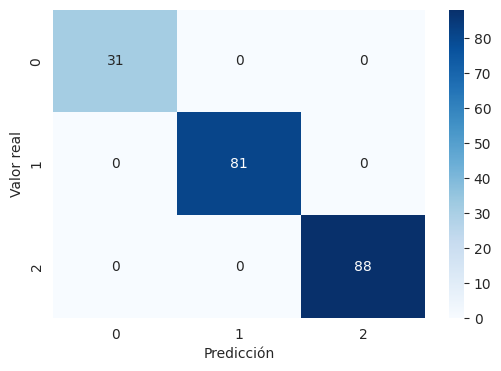

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

## 4. Importancia de variables

          Variable  Importancia
0             eCo2     0.522406
1         Longitud     0.144944
2      Temperatura     0.119096
3          Humedad     0.063992
7             Hora     0.056412
4          Latitud     0.053912
5  Señal Detectada     0.029281
6            Redes     0.009958


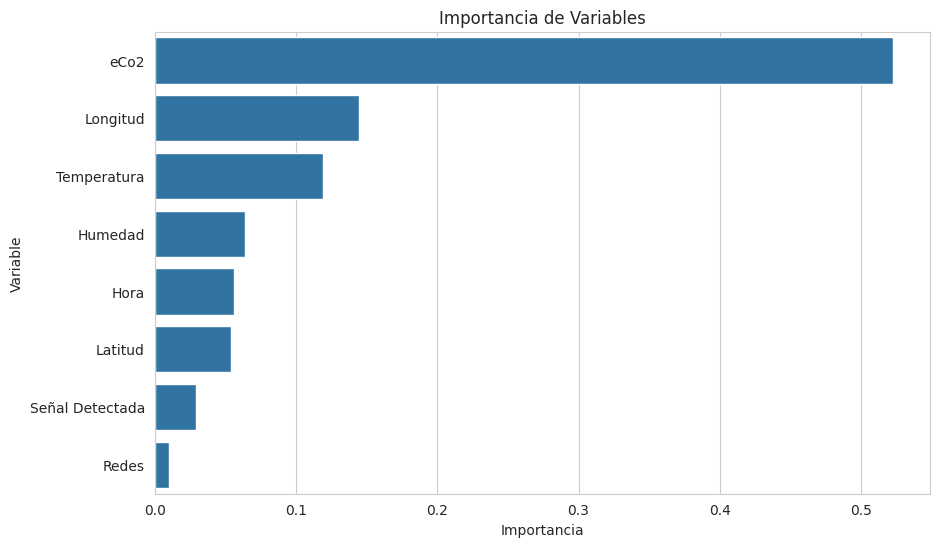

In [ ]:
importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf.feature_importances_
})

importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

print(importancias)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importancias,
    x="Importancia",
    y="Variable"
)

plt.title("Importancia de Variables")
plt.show()

# Aplicación XAI

## SHAP


## 1. Instalar SHAP

Se instaló la librería **SHAP** mediante `pip install shap` para generar explicaciones del modelo basadas en importancia de características.


In [ ]:
!pip install shap -q

## 2. Importar librerías

Se importaron las librerías `shap` y `matplotlib` para generar las explicaciones del modelo y visualizar los gráficos de importancia de característica

In [ ]:
import shap
import matplotlib.pyplot as plt

## 3. Creación del explicador

Se inicializó el objeto `TreeExplainer` de SHAP usando el modelo Random Forest entrenado, permitiendo calcular las contribuciones de cada característica en las predicciones.


In [ ]:
explainer = shap.TreeExplainer(rf)

## 4. Calcular valores SHAP

Se calcularon los valores SHAP para el conjunto de prueba usando `TreeExplainer`, obteniendo las contribuciones de cada característica en las predicciones del modelo.

In [ ]:
shap_values = explainer.shap_values(X_test)

## 5. Importancia global de variables

El gráfico de importancia global muestra la contribución promedio de cada variable en las predicciones del modelo. Las variables con mayor valor SHAP medio absoluto tienen una influencia más significativa en la clasificación del nivel de aforo.

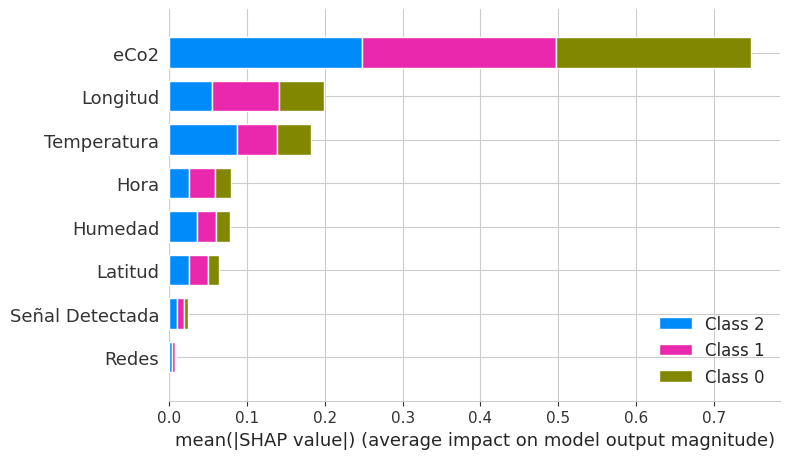

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)



## 6. SHAP Summary Plot para la clase 0, clase 1, clase 2


Se generó el gráfico *summary plot* para la clase 0, mostrando la influencia global de cada característica en la predicción del nivel de aforo alto.


Se generó el gráfico *summary plot* utilizando los valores SHAP correspondientes a la clase 1, permitiendo visualizar la influencia global de cada característica en la predicción del nivel de aforo bajo.

Se generó el gráfico *summary plot* para la clase 2, mostrando la influencia global de cada característica en la predicción del nivel de aforo medio.

Interpretación

Color rojo → valores altos.

Color azul → valores bajos.

Derecha → aumenta la probabilidad de la clase.

Izquierda → disminuye la probabilidad.


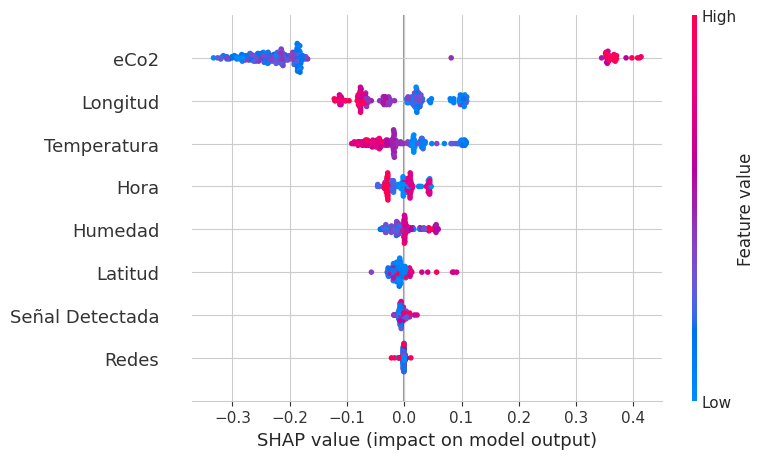

In [ ]:
#Clase 0 → AFORO ALTO
shap.summary_plot(
    shap_values[:, :, 0],
    X_test,
    feature_names=X_test.columns,
    plot_type="dot"
)

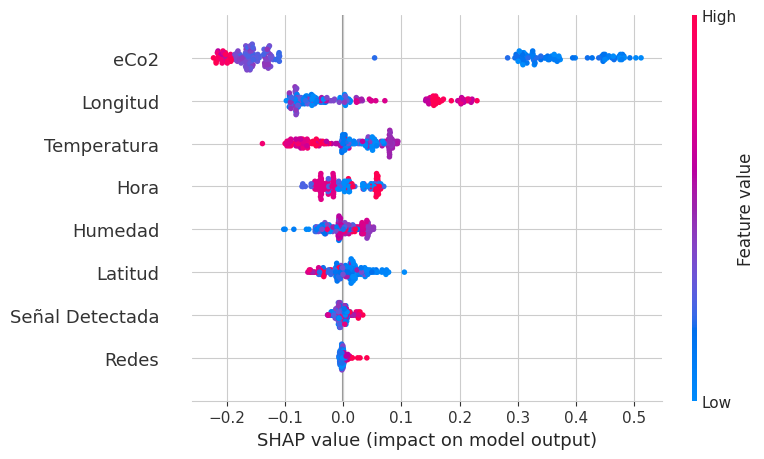

In [ ]:
#Clase 1 → AFORO BAJO
shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    feature_names=X_test.columns
)

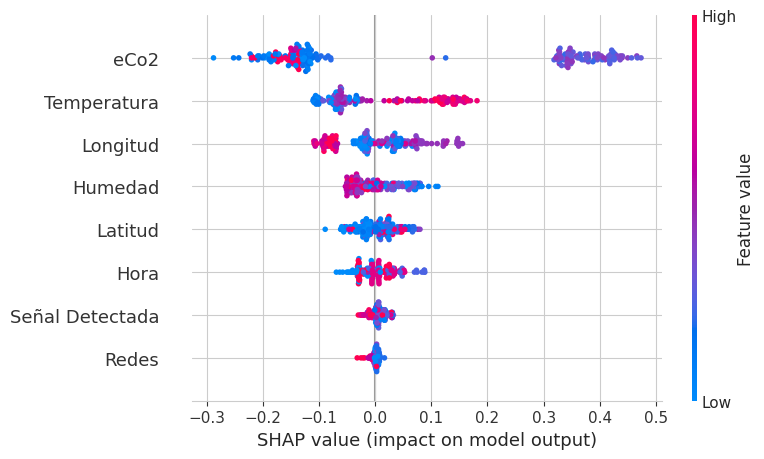

In [ ]:
#Clase 2 → AFORO MEDIO
shap.summary_plot(
    shap_values[:, :, 2],
    X_test,
    feature_names=X_test.columns
)

El análisis conjunto de los gráficos SHAP importancia global, importancia por clase y contribuciones puntuales revela que la influencia de cada variable en el modelo no es uniforme, sino que depende del nivel de análisis (global, por clase o por muestra).

En términos globales, la variable eCO₂ es la más influyente del modelo, debido a su amplio rango de variación y su fuerte relación con el nivel de ocupación. Sin embargo, los summary plots por clase muestran que esta importancia no se distribuye de manera homogénea entre las tres clases de aforo.

Para la clase 0 (Aforo Bajo), las variables más determinantes son Longitud y Latitud, lo que indica que la ubicación geográfica del vehículo es el principal indicador de baja ocupación. En esta clase, eCO₂ tiene una contribución menor porque los valores de CO₂ suelen ser moderados cuando hay poca gente.

En la clase 1 (Aforo Medio), la influencia se reparte entre Temperatura, Humedad y eCO₂, mostrando que las condiciones ambientales y la ventilación comienzan a tener un papel más relevante.

En la clase 2 (Aforo Alto), eCO₂ vuelve a ser una de las variables más influyentes, ya que los niveles elevados de CO₂ son un indicador directo de alta ocupación.

